### **Sistema de Análise de Irrigação Agrícola**

In [9]:
# Importação das bibliotecas
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro, kstest, probplot
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
from statsmodels.graphics.gofplots import qqplot

**Carga dos dados**

In [10]:
# Abrir o dataset
df_irrigacao = pd.read_csv('./datasets/dados_de_irrigacao.csv')

In [11]:
# Checar estrutura do Dataset
df_irrigacao.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Horas de Irrigação        299 non-null    int64  
 1   Área Irrigada             299 non-null    int64  
 2   Área Irrigada por Ângulo  299 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 7.1 KB


In [12]:
# Visualizar topo do dataset
df_irrigacao.head()

,Horas de Irrigação,Área Irrigada,Área Irrigada por Ângulo
0,1,100,66.666667
1,2,200,133.333333
2,3,300,200.000000
3,4,400,266.666667
4,5,500,333.333333


In [13]:
# Visualizar final do dataset
df_irrigacao.tail()

,Horas de Irrigação,Área Irrigada,Área Irrigada por Ângulo
294,295,29500,19666.666667
295,296,29600,19733.333333
296,297,29700,19800.000000
297,298,29800,19866.666667
298,299,29900,19933.333333


**EDA**

In [14]:
# Medidas estatísticas das variáveis
df_irrigacao.describe()

,Horas de Irrigação,Área Irrigada,Área Irrigada por Ângulo
count,299.000000,299.000000,299.000000
mean,150.000000,15000.000000,10000.000000
std,86.458082,8645.808233,5763.872155
min,1.000000,100.000000,66.666667
25%,75.500000,7550.000000,5033.333333
50%,150.000000,15000.000000,10000.000000
75%,224.500000,22450.000000,14966.666667
max,299.000000,29900.000000,19933.333333


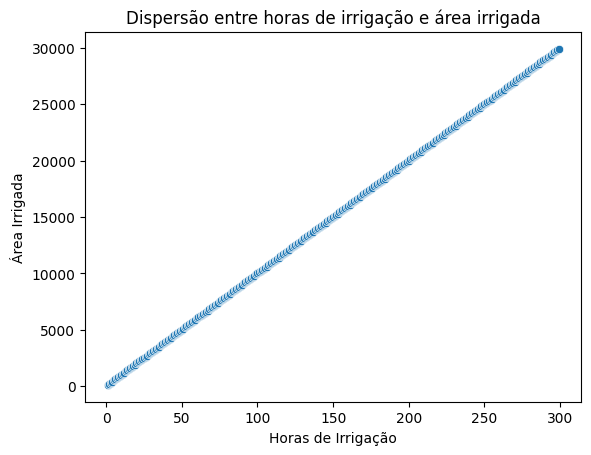

In [18]:
# Plot de dispersão
# X = horas de irrigação
# y = area irrigada

sns.scatterplot(x='Horas de Irrigação', y='Área Irrigada', data=df_irrigacao);
plt.title('Dispersão entre horas de irrigação e área irrigada');

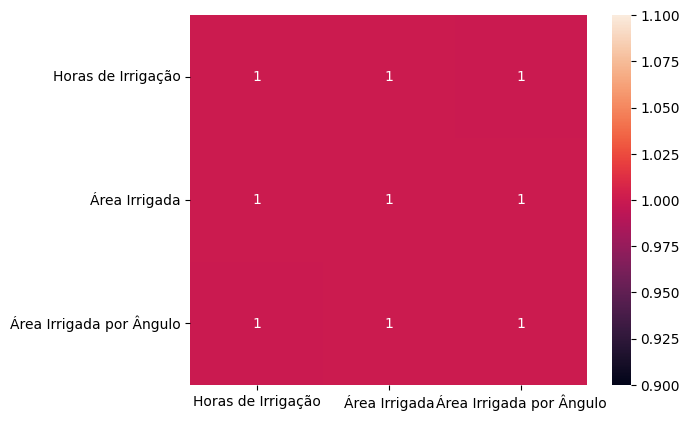

In [ ]:
# Verificar Correlação - Pearson
sns.heatmap(df_irrigacao.corr('pearson'), annot = True);

A relação linear é direta: as variáveis apresental correlação positiva perfeita (1.0). A área irrigada é diretamente proporcional às horas de irrigação.

**Treino do modelo**

In [25]:
# Dividir dataset entre treino e teste
# Quando temos apenas uma varável dependente, precisamos ajustar o shape
X = df_irrigacao['Horas de Irrigação'].values.reshape(-1, 1)
y = df_irrigacao['Área Irrigada por Ângulo'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

In [26]:
# Instanciar o modelo de Regressão Linear
reg_model = LinearRegression()

In [27]:
# Treinar o modelo
reg_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
# Imprimir a equação da reta
# y = aX + b
print("A equação da reta é y = {:4f}x + {:4f}".format(reg_model.coef_[0][0], reg_model.intercept_[0]))

A equação da reta é y = 66.666667x + 0.000000


O intercepto da equação da reta é zero, indicando que a linha passa pela origem do plano cartesiano. Assim, o modelo ajustado é uma função linear direta, sem deslocamento vertical, cruzando o eixo y no ponto zero.

**Validação do modelo - Métricas**

In [29]:
# Predição dos valores com base no conjunto de testes
y_pred = reg_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Calcular a métrica MAE - Mean Absolute Error
# MAE = média (y_test - y_pred)
# É uma métrica fácil de interpretar, pois é a média dos erros absolutos entre os valores reais e os valores previstos. 
# Quanto menor o MAE, melhor o desempenho do modelo.
# MAE é menos sensível a outliers do que o MSE, pois não eleva os erros ao quadrado.
# Isso significa que o MAE pode ser uma escolha mais apropriada quando os dados contêm outliers ou quando se deseja uma métrica que seja mais robusta a valores extremos.
mean_absolute_error(y_test, y_pred)

1.8764644159495625e-12

In [34]:
# Calcular a métrica MSE - Mean Squared Error
# MSE = média (y_test - y_pred)²
# O MSE é uma métrica que penaliza mais os erros maiores, pois eleva os erros ao quadrado.
# Isso significa que o MSE pode ser mais sensível a outliers do que o MAE, pois os erros maiores terão um impacto desproporcionalmente maior na métrica. 
# O MSE é útil quando se deseja enfatizar a importância de grandes erros, mas pode ser menos interpretável do que o MAE, especialmente quando os erros são expressos em unidades quadráticas.
# Não é tão fácil de interpretar, pois é a média dos erros quadráticos entre os valores reais e os valores previstos. 
# Quanto menor o MSE, melhor o desempenho do modelo.
mean_squared_error(y_test, y_pred)

5.0788674199138044e-24

In [41]:
# Calcular métrica R-squared ou Coeficiente de Determinação
# R2 representa a proporção na variação da variável dependente que é explicada pela variável independente
r2_score(y_test, y_pred)

1.0

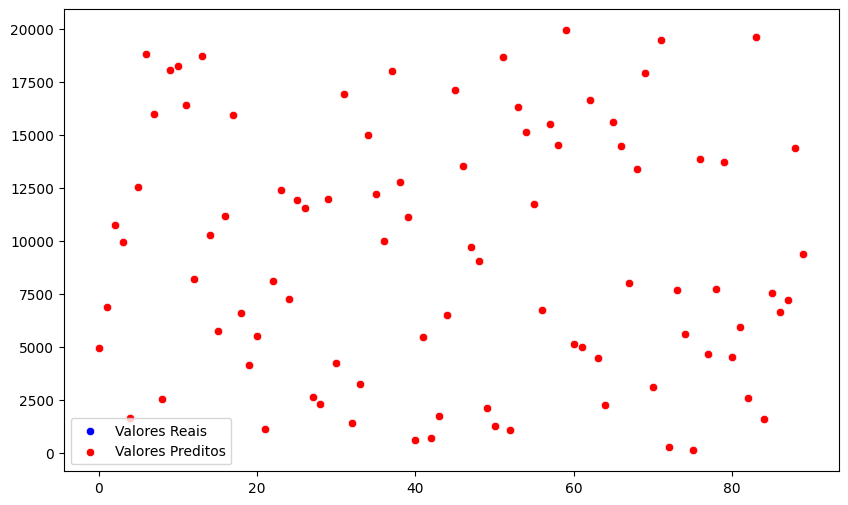

In [35]:
# Análise gráfica
x_axis = range(len(y_test))
plt.figure(figsize=(10, 6))

sns.scatterplot(x = x_axis, y = y_test.reshape(-1), color = 'blue', label = 'Valores Reais');
sns.scatterplot(x = x_axis, y = y_pred.reshape(-1), color = 'red', label = 'Valores Preditos');

plt.legend()
plt.show();

O modelo apresentou ajuste perfeito, com R^2 = 1.0 e métricas de erro (MAE e MSE) virtualmente zero. Isso indica que 100% da variabilidade da `Área Irrigada` é explicada pelas `Horas de Irrigação`. Graficamente, a reta de regressão y = 66.67x sobrepõe-se exatamente aos dados reais. Essa aderência total confirma que a relação entre as variáveis é puramente determinística (matemática exata), sem a presença de ruído aleatório ou erro amostral.

**Análise de Resíduos**

In [36]:
# Calcular resíduos
residuos = y_test - y_pred

In [37]:
# Calcular os resíduos padronizados (standardization)
# Para cada elemento de um conjunto (X - media) / desvio padrão
from scipy.stats import zscore
residuos_std = zscore(residuos)

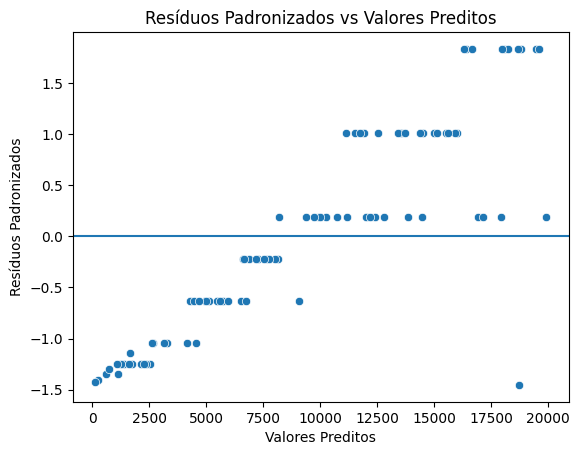

In [ ]:
# Verificar linearidade do modelo
# Se os resíduos estiverem entre -2 e 2 (na escala padronizada), o modelo é linear

# Verificar homogeneidade das variâncias (homoscedasticidade)
# Se os valores ficam em torno da reta, temos homoscedasticidade. 
# Se os resíduos se afastarem da reta, temos heteroscedasticidade.

sns.scatterplot(x=y_pred.reshape(-1), y=residuos_std.reshape(-1));
plt.axhline(y=0);
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos Padronizados')
plt.title('Resíduos Padronizados vs Valores Preditos')
plt.show()

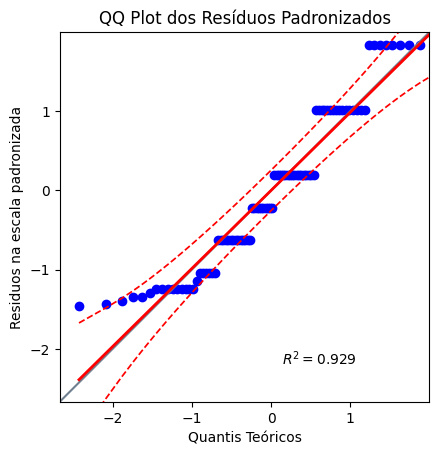

In [ ]:
# Checar se resíduos seguem uma distribuição normal
# QQ Plot (Quantile-Quantile Plot), que avalia se uma amostra segue uma distribuição teórica, como a normal. 
# Se os pontos do gráfico formarem uma linha reta, os resíduos seguem uma distribuição normal. 
# Se os pontos se afastarem significativamente da linha reta, os resíduos podem não seguir uma distribuição normal.
import pingouin as pg

pg.qqplot(residuos_std, dist='norm', confidence=0.95);
plt.xlabel('Quantis Teóricos');
plt.ylabel('Residuos na escala padronizada');
plt.title('QQ Plot dos Resíduos Padronizados');
plt.show();

Os gráficos de resíduos revelam um comportamento artificial. O plot de dispersão exibe padrões em linha e o QQ Plot apresenta um formato em 'degraus', sugerindo desvios de homocedasticidade e normalidade. 

Contudo, como o modelo é puramente determinístico e o erro real é zero, tais padrões são artefatos computacionais. O comportamento decorre estritamente de limites de precisão de ponto flutuante, onde os ruídos microscópicos de arredondamento (MAE aproximadamente 10^-12) foram artificialmente amplificados e discretizados pelo processo de padronização.

In [42]:
# Teste de Shapiro-Wilk para normalidade dos resíduos
# O teste de Shapiro-Wilk é um teste estatístico usado para avaliar a normalidade de um conjunto de dados. 
# Ele é especialmente útil para amostras pequenas a moderadas. 
# O teste verifica se os dados seguem uma distribuição normal, comparando a distribuição dos dados com uma distribuição normal teórica. 
# O resultado do teste inclui um valor-p, que indica a probabilidade de obter os dados observados se a hipótese nula (de que os dados seguem uma distribuição normal) for verdadeira. 
# Se o valor-p for menor que um nível de significância pré-determinado (geralmente 0,05), rejeitamos a hipótese nula, indicando que os dados não seguem uma distribuição normal.
stat_shapiro, p_valor_shapiro = shapiro(residuos.reshape(-1))
print("Estatística do teste de Shapiro-Wilk: {} e valor-p: {}".format(stat_shapiro, p_valor_shapiro))

Estatística do teste de Shapiro-Wilk: 0.9188782351154261 e valor-p: 3.150814299065697e-05


In [43]:
# Teste de normalidade de Kolmogorov-Smirnov
# O teste de Kolmogorov-Smirnov é um teste estatístico usado para avaliar a normalidade de um conjunto de dados.
# Ele compara a distribuição dos dados com uma distribuição normal teórica, calculando a distância máxima entre as duas distribuições.
# O resultado do teste inclui um valor-p, que indica a probabilidade de obter os dados observados se a hipótese nula (de que os dados seguem uma distribuição normal) for verdadeira. 
# Se o valor-p for menor que um nível de significância pré-determinado (geralmente 0,05), rejeitamos a hipótese nula, indicando que os dados não seguem uma distribuição normal.
stat_ks, p_valor_ks = kstest(residuos.reshape(-1), 'norm')
print("Estatística do teste de Kolmogorov-Smirnov: {} e valor-p: {}".format(stat_ks, p_valor_ks))

Estatística do teste de Kolmogorov-Smirnov: 0.49999999999854866 e valor-p: 2.4869515023142266e-21


Os testes formais confirmam a rejeição da normalidade dos resíduos com significância estatística extrema, dado que os valores-p de Shapiro-Wilk (3.15 x 10^-5) e Kolmogorov-Smirnov (2.48 x 10^-21) são inferiores a 0.05.

Essa rejeição e o formato escalonado do QQ Plot, contudo, reforçam o diagnóstico de que os resíduos não representam erros estocásticos de um fenômeno real. Trata-se da quebra de continuidade numérica causada pelo arredondamento de ponto flutuante de valores microscópicos próximos de zero, inviabilizando a aplicação conceitual das premissas clássicas de normalidade neste cenário determinístico.